In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

In [8]:
from catrace.exp_collection import read_df
from catrace.dataset import load_dataset_config

In [9]:
dsconfig = load_dataset_config('../juvenile_dataset_without14mm_phearg.json')

/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type odors_learned detected when decoding DatasetConfig.
  warnings.warn(
/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type odors_novel detected when decoding DatasetConfig.
  warnings.warn(
/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type onsets detected when decoding DatasetConfig.
  warnings.warn(


In [10]:
dsconfig.exp_list

[('2021-07-15-DpOBEM-N2_Dp', 'naive'),
 ('2021-07-16-DpOBEM-N3_Dp', 'naive'),
 ('2021-12-10-DpOBEM-N4_Dp', 'naive'),
 ('2021-12-31-DpOBEM-N7_Dp', 'naive'),
 ('2022-02-13-DpOBEM-N10_Dp', 'naive'),
 ('2022-02-20-DpOBEM-N11_Dp', 'naive'),
 ('2021-02-05-DpOBEM-JH9_Dp', 'phe-arg'),
 ('2021-03-18-DpOBEM-JH10_Dp', 'phe-arg'),
 ('2021-03-19-DpOBEM-JH10_Dp', 'phe-arg'),
 ('2021-04-02-DpOBEM-JH11_Dp', 'phe-arg'),
 ('2021-04-03-DpOBEM-JH11_Dp', 'phe-arg'),
 ('2021-05-01-DpOBEM-JH13_Dp', 'phe-arg'),
 ('2021-05-22-DpOBEM-JH14_Dp', 'phe-arg'),
 ('2021-09-15-DpOBEM-JH20_Dp', 'phe-arg'),
 ('2021-09-17-DpOBEM-JH20_Dp', 'phe-arg'),
 ('2021-09-18-DpOBEM-JH20_Dp', 'phe-arg'),
 ('2021-07-30-DpOBEM-JH17_Dp', 'arg-phe'),
 ('2021-07-31-DpOBEM-JH17_Dp', 'arg-phe'),
 ('2021-09-02-DpOBEM-JH18_Dp', 'arg-phe'),
 ('2021-09-03-DpOBEM-JH18_Dp', 'arg-phe'),
 ('2021-09-04-DpOBEM-JH18_Dp', 'arg-phe'),
 ('2021-09-29-DpOBEM-JH21_Dp', 'arg-phe'),
 ('2021-10-01-DpOBEM-JH21_Dp', 'arg-phe'),
 ('2021-10-02-DpOBEM-JH21_Dp', 'ar

In [11]:
exp_name = '2021-10-01-DpOBEM-JH21_Dp'
dff = read_df(dsconfig.processed_trace_dir, exp_name)

dff = dff * dsconfig.frame_rate # IMPORTANT: convert spike probability to spike rate

2021-10-01-DpOBEM-JH21_Dp None


In [12]:
dff.shape

(2898, 1747)

MultiIndex([(2, 346, 1184),
            (1, 210,  589),
            (0, 228,  212),
            (2, 431, 1269),
            (0, 306,  289),
            (3, 307, 1593),
            (1, 437,  812),
            (2, 352, 1190),
            (3, 306, 1592),
            (2, 139,  977),
            (1, 421,  796),
            (2, 447, 1285),
            (3, 305, 1591),
            (1, 382,  758),
            (3,   9, 1297),
            (1, 384,  760),
            (3,  41, 1328),
            (3, 360, 1646),
            (2, 275, 1113),
            (2,  33,  873),
            (3, 439, 1725),
            (1, 298,  675),
            (0,  58,   50),
            (3, 167, 1454),
            (2, 249, 1087),
            (2,  55,  895),
            (3, 340, 1626),
            (3,  23, 1311),
            (3, 222, 1509),
            (0, 375,  353),
            (2,  97,  937),
            (2, 332, 1170),
            (2, 291, 1129),
            (3,  17, 1305),
            (3,  60, 1347),
            (0,  66,

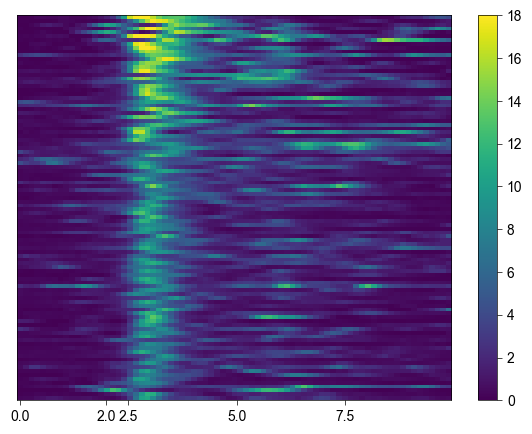

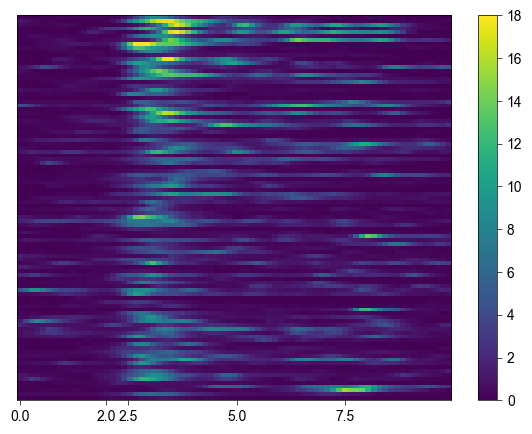

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from catrace.visualize import load_colormap

def plot_example_heatmap(edff, frame_rate, figsize=(7, 5), vmin=0, vmax=1, cmap='viridis', gamma=0.5):
    if cmap == 'clut2b':
        cmap = load_colormap('clut2b', remove_top_white=True)
    fig, ax = plt.subplots(figsize=figsize)
    # Power normalize the heatmap
    from matplotlib.colors import PowerNorm
    if gamma is not None:
        norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)
        img = ax.matshow(edff, aspect='auto', cmap=cmap, norm=norm)
    else:
        img = ax.matshow(edff, aspect='auto', cmap=cmap)

    # Plot the heatmap with color limits
    #img = ax.matshow(edff, aspect='auto', vmin=vmin, vmax=vmax, cmap=cmap)

    # Convert x axis from frame to time
    xticks = np.arange(0, edff.shape[1], 2.5 * frame_rate)
    # append 2*frame_rate to xticks
    xticks = np.append(xticks, 2 * frame_rate)
    ax.set_xticks(xticks)
    xticklabels = xticks / frame_rate
    ax.set_xticklabels(xticklabels)

    # Put the x tick label at the bottom
    ax.xaxis.set_ticks_position('bottom')
    # remove x tick label at the top
    ax.tick_params(axis='x', which='both', bottom=True, top=False)

    # Remove y ticks
    ax.set_yticks([])
    ax.set_yticklabels([])

    # Set xlim
    # xlim = ax.get_xlim()
    # ax.set_xlim((0, xlim[1] * frame_rate))
    colorbar = fig.colorbar(img)
    return fig, ax, img, colorbar

# Save figure
paper_fig_dir = '../../../figures_for_paper'

from catrace.for_paper import save_figure_for_paper
dataset_name = 'juvenile'


#trial_number = 1
def plot_and_save_example_heatmap(odor, trial_number,  neuron_idxs, frame_range, sorted_neuron_idxs=None, cut_first=None,cut_last=None,**kwargs):
    edff = dff.xs((odor, trial_number), level=['odor', 'trial']).T.iloc[neuron_idxs, frame_range[0]:frame_range[1]]
    mean_response = edff.iloc[:, 15:38].mean(axis=1)
    if sorted_neuron_idxs is None:
        sorted_neuron_idxs = mean_response.sort_values(ascending=False).index
    if cut_first is not None:
        sorted_neuron_idxs = sorted_neuron_idxs[cut_first:]
    if cut_last is not None:
        sorted_neuron_idxs = sorted_neuron_idxs[:-cut_last]
    edff_sorted = edff.loc[sorted_neuron_idxs]
    fig, ax, img, colorbar = plot_example_heatmap(edff_sorted, dsconfig.frame_rate, figsize=(7, 5), **kwargs)

    #num_neurons = neuron_idxs.stop - neuron_idxs.start
    num_neurons = len(sorted_neuron_idxs)
    fig_name = f'{dataset_name}_example_heatmap_{exp_name}_{odor}_num_neurons{num_neurons}'
    save_figure_for_paper(fig, fig_name, paper_fig_dir)
    return sorted_neuron_idxs

#start_idx = 850
#num_neurons = 200
#neuron_idxs = slice(start_idx, start_idx + num_neurons)
neuron_idxs = slice(0, dff.shape[1])
vmin = 0 * dsconfig.frame_rate
vmax = 18#1.2 * dsconfig.frame_rate

cut_time = 2.3 # seconds
cut_frame = int(cut_time * dsconfig.frame_rate)
total_time =10
total_frame = int(total_time * dsconfig.frame_rate)
frame_range = (cut_frame, cut_frame + total_frame)

gamma = 1#0.5
sorted_neuron_idxs = plot_and_save_example_heatmap('Arg', 1, neuron_idxs_chosen, frame_range, vmin=vmin, vmax=vmax, cmap='viridis', sorted_neuron_idxs=None, cut_first=0, cut_last=len(neuron_idxs_chosen)-100, gamma=gamma) #total_num_neurons
plot_and_save_example_heatmap('Phe', 0, neuron_idxs_chosen, frame_range, vmin=vmin, vmax=vmax, cmap='viridis', sorted_neuron_idxs=sorted_neuron_idxs, gamma=gamma)

In [ ]:
# Plot selected single traces
# roi_ids = [427, 318, 321, 382, 429, 443, 405, 437, 209, 351]
#roi_ids = [209, 318, 321, 351, 382, 405, 427, 429, 437, 443]

# Changed ROI id from 429 to 421
# roi_ids = [269, 318, 321, 351, 382, 405, 427, 421, 437, 443]
# roi_ids = [269, 318, 321, 351, 382, 405, 427, 421, 437, 443]
roi_ids = [269, 318, 321, 351, 382, 405, 427, 429, 437, 443]
# Discard 443, 427



In [ ]:
plane = 1 # Plane number 2
trial = ('Arg', 0)
plane_dff = dff.T.xs(plane, level='plane')
neurons = plane_dff.index.get_level_values('neuron').isin(roi_ids)
example_dff = plane_dff[neurons].T.xs(trial, level=['odor', 'trial'])
example_dff.max()

In [ ]:
plane = 1 # Plane number 2
trial = ('Arg', 0)

def plot_example_traces(dff, plane, trial, roi_ids,
                        cut_time=2.3, # seconds
                        total_time=10,
                        **kwargs):
    plane_dff = dff.T.xs(plane, level='plane')
    neurons = plane_dff.index.get_level_values('neuron').isin(roi_ids)
    example_dff = plane_dff[neurons].T.xs(trial, level=['odor', 'trial'])
    cut_frame = int(cut_time * dsconfig.frame_rate)
    total_frame = int(total_time * dsconfig.frame_rate)
    frame_range = (cut_frame, cut_frame + total_frame)
    cut_example_dff = example_dff.iloc[frame_range[0]:frame_range[1], :]
    frame_vec = cut_example_dff.index
    time_vec = frame_vec / dsconfig.frame_rate - cut_time
    fig = plot_per_neuron(cut_example_dff, time_vec, **kwargs)
    return fig

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def plot_per_neuron(cut_example_dff, time_vec,
                    spacing=3.0,
                    figsize=(1.0, 1.4), linewidth=0.5,
                    show_legend=False):
    fig, ax = plt.subplots(figsize=figsize)

    for i, neuron in enumerate(cut_example_dff.columns):
        ax.plot(time_vec, cut_example_dff[neuron] + i * spacing, label=f'Neuron {neuron}', linewidth=linewidth)

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    # Define the scale bar lengths
    x_bar_length = 2  # 2 seconds
    y_bar_length = 1  # dF/F units

    # Adjusted positions to move the scale bars more to the left and bottom
    x_bar_start = x_min + 0.01 * (x_max - x_min)
    y_bar_start = y_min + 0.01 * (y_max - y_min)

    # Draw x-axis scale bar
    ax.hlines(y=y_bar_start, xmin=x_bar_start, xmax=x_bar_start + x_bar_length, linewidth=linewidth, color='black')
    ax.text(x_bar_start + x_bar_length / 2, y_bar_start - 0.02 * (y_max - y_min), '2 s', ha='center', va='top', fontsize=6)

    # Draw y-axis scale bar
    ax.vlines(x=x_bar_start, ymin=y_bar_start, ymax=y_bar_start + y_bar_length, linewidth=linewidth, color='black')
    ax.text(x_bar_start - 0.02 * (x_max - x_min), y_bar_start + y_bar_length / 2, '1', ha='right', va='center', fontsize=6)
    if show_legend:
        ax.legend(loc='upper right', fontsize=6)
    return fig

fig = plot_example_traces(dff, plane, trial, roi_ids, spacing=3.0*dsconfig.frame_rate, show_legend=False)
dataset_name = 'juvenile'
fig_name = f'{dataset_name}_example_traces_per_neuron_{exp_name}_Arg'
save_figure_for_paper(fig, fig_name, paper_fig_dir)

In [ ]:
fig = plot_example_traces(dff, plane, trial, roi_ids, spacing=3.0, show_legend=True)
fig.tight_layout()
fig_name = f'{dataset_name}_example_traces_per_neuron_legend_{exp_name}_Arg'
save_figure_for_paper(fig, fig_name, paper_fig_dir)

In [ ]:
from os.path import join as pjoin
dfovf_dir = pjoin(dsconfig.db_dir, 'dfovf_long')
dfovf_dff = read_df(dfovf_dir, exp_name.replace('_Dp', ''))
#dfovf_dff = dfovf_dff.unstack(level=['plane', 'neuron'])

In [ ]:
plane = 1 # Plane number 2
trial = ('arg', 0)
cut_time = 2.6 + 5# seconds
totoal_time = 10
fig = plot_example_traces(dfovf_dff, plane, trial, roi_ids,
                          spacing=4.4,
                          cut_time=cut_time, total_time=total_time)
dataset_name = 'juvenile'
fig_name = f'{dataset_name}_dfovf_example_traces_per_neuron_{exp_name}_Arg'
save_figure_for_paper(fig, fig_name, paper_fig_dir)